<a href="https://colab.research.google.com/github/harshit-46/machine-learning-0-100/blob/main/nyc_taxi_ridge_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚕 NYC Yellow Taxi — Fare Price Prediction
## Ridge Regression Baseline Model
---
**Dataset:** NYC Yellow Taxi Trip Records  
**Target:** `fare_amount` (in USD)  
**Approach:** Ridge Regression baseline with full EDA, feature engineering, alpha tuning, and comparison vs Linear Regression


## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("✅ Libraries loaded")


✅ Libraries loaded


## 2. 📂 Load Dataset

In [3]:
df = pd.read_csv("yellow_tripdata_2016-03.csv")


print("=== Column Types ===")
print(df.dtypes)
print("\n=== Null Values ===")
print(df.isnull().sum())
print("\n=== Statistical Summary ===")
df.describe()


=== Column Types ===
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

=== Null Values ===
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type        

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120330.000000,120329.000000,120329.000000
mean,1.822671,1.869326,3.000934,-73.233368,40.345108,1.038984,-73.257975,40.358531,1.333682,12.963184,0.084613,0.497183,1.836242,0.355869,0.299544,16.036673
std,0.381948,1.549890,3.795780,7.365812,4.054475,0.276751,7.241231,3.987186,0.480555,11.481982,0.188284,0.041280,2.563453,1.506535,0.015870,14.221320
min,1.000000,0.000000,0.000000,-121.933327,0.000000,1.000000,-121.933327,0.000000,1.000000,-47.000000,-0.500000,-0.500000,-2.700000,0.000000,-0.300000,-47.300000
25%,2.000000,1.000000,1.000000,-73.990944,40.739239,1.000000,-73.990156,40.739530,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.300000
50%,2.000000,1.000000,1.670000,-73.979950,40.755611,1.000000,-73.978233,40.755489,1.000000,9.500000,0.000000,0.500000,1.260000,0.000000,0.300000,11.760000
75%,2.000000,2.000000,3.130000,-73.963387,40.769695,1.000000,-73.962425,40.767590,2.000000,14.500000,0.000000,0.500000,2.360000,0.000000,0.300000,17.760000
max,2.000000,6.000000,184.400000,0.000000,41.204548,6.000000,0.000000,42.666893,4.000000,819.500000,4.500000,0.500000,125.880000,30.540000,0.300000,832.800000


## 3. 🧹 Data Cleaning
Based on the dataset statistics we can see:
- `fare_amount` has negatives (min = -52) → remove
- `trip_distance` has 0-distance trips → remove
- Coordinates contain 0.0 values (invalid) → filter to NYC bounding box
- `RatecodeID` has value 99 (unknown) → remove
- 1 null row per column → drop


In [4]:
print(f"Original rows: {len(df):,}")

# Drop nulls (only 1 row affected)
df.dropna(inplace=True)

# Convert datetime columns
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Compute trip duration in minutes
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# ── Filter rules ──────────────────────────────────────────────────────────
df = df[df['fare_amount'].between(2.5, 300)]          # valid fare range
df = df[df['trip_distance'].between(0.1, 100)]        # valid distance
df = df[df['passenger_count'].between(1, 6)]          # valid passengers
df = df[df['trip_duration_min'].between(1, 180)]      # 1 min – 3 hours
df = df[df['RatecodeID'].isin([1, 2, 3, 4, 5, 6])]   # remove code 99

# NYC bounding box
df = df[
    df['pickup_longitude'].between(-74.05, -73.75) &
    df['pickup_latitude'].between(40.60, 40.90) &
    df['dropoff_longitude'].between(-74.05, -73.75) &
    df['dropoff_latitude'].between(40.60, 40.90)
]

df.reset_index(drop=True, inplace=True)
print(f"Clean rows:    {len(df):,}")
print(f"Removed:       {300000 - len(df):,} rows")


Original rows: 120,330
Clean rows:    117,273
Removed:       182,727 rows


## 4. 🔍 Exploratory Data Analysis (EDA)

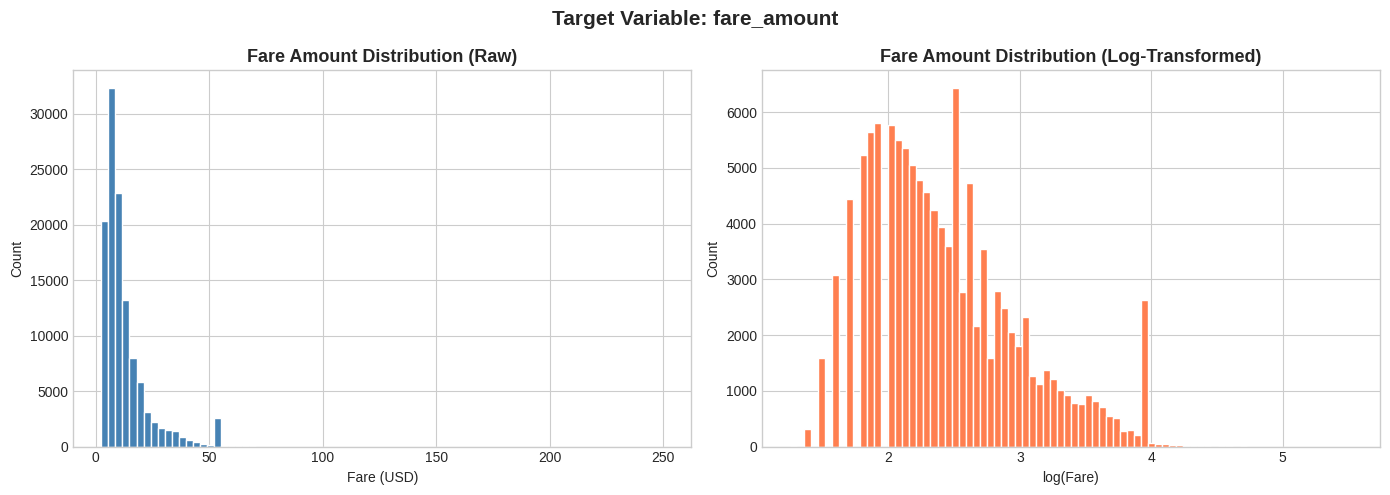

Mean fare:   $12.68
Median fare: $9.50
Std fare:    $10.04


In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['fare_amount'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Fare Amount Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fare (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['fare_amount']), bins=80, color='coral', edgecolor='white')
axes[1].set_title('Fare Amount Distribution (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Fare)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: fare_amount', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean fare:   ${df['fare_amount'].mean():.2f}")
print(f"Median fare: ${df['fare_amount'].median():.2f}")
print(f"Std fare:    ${df['fare_amount'].std():.2f}")


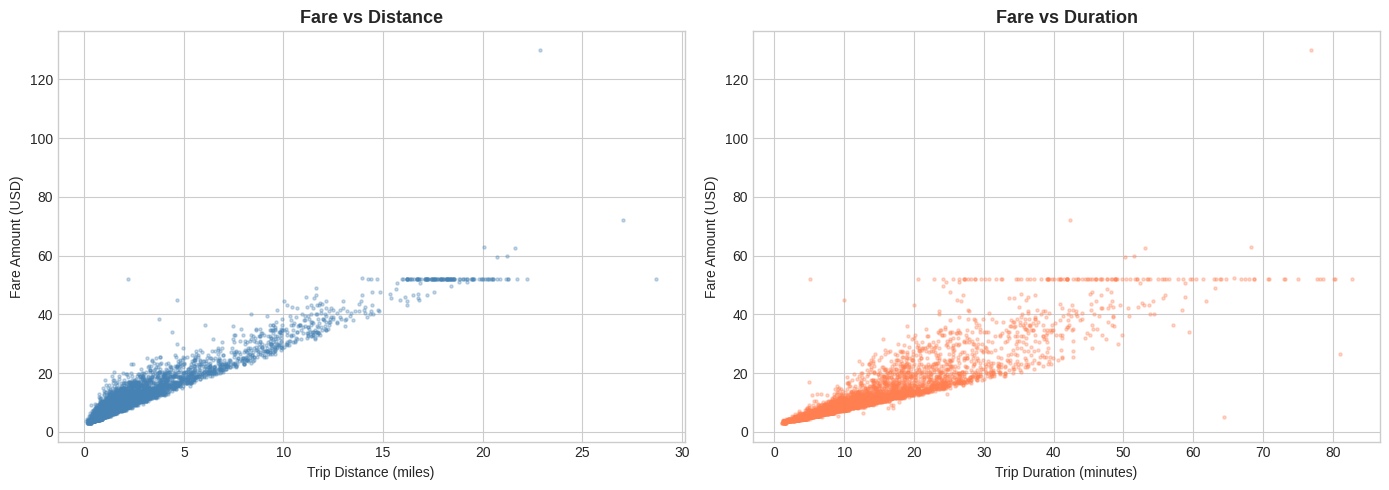

In [6]:
# Fare vs distance scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(5000, random_state=42)

axes[0].scatter(sample['trip_distance'], sample['fare_amount'],
                alpha=0.3, s=5, color='steelblue')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Fare Amount (USD)')
axes[0].set_title('Fare vs Distance', fontsize=13, fontweight='bold')

axes[1].scatter(sample['trip_duration_min'], sample['fare_amount'],
                alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('Trip Duration (minutes)')
axes[1].set_ylabel('Fare Amount (USD)')
axes[1].set_title('Fare vs Duration', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


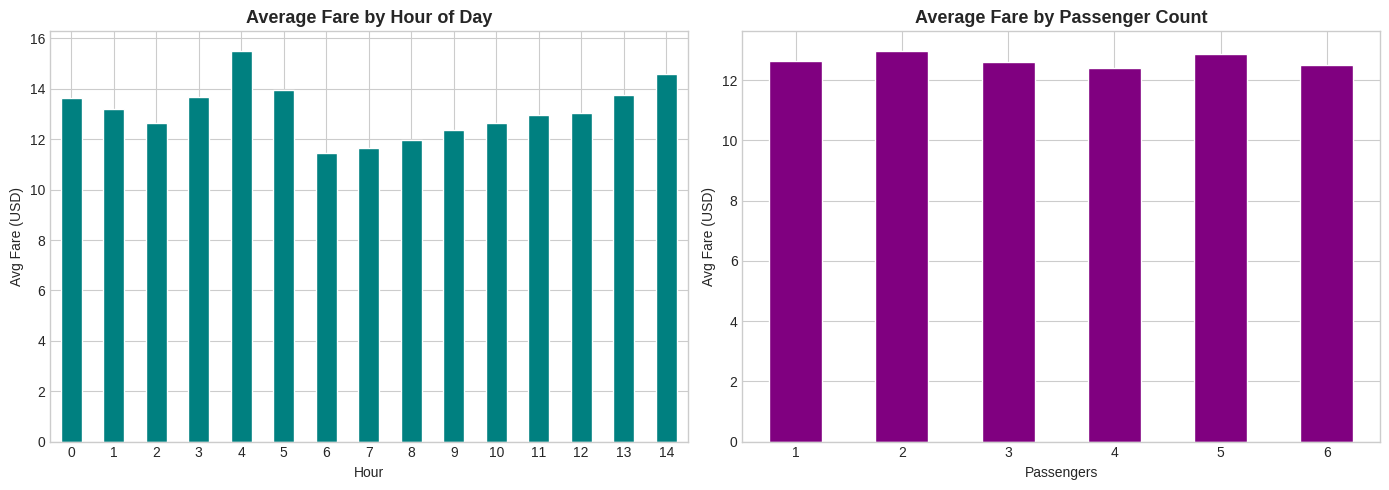

In [7]:
# Average fare by hour of day
df['hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_fare = df.groupby('hour')['fare_amount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_fare.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Average Fare by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Fare (USD)')
axes[0].tick_params(axis='x', rotation=0)

# Fare by passenger count
df.groupby('passenger_count')['fare_amount'].mean().plot(
    kind='bar', ax=axes[1], color='purple', edgecolor='white'
)
axes[1].set_title('Average Fare by Passenger Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Passengers')
axes[1].set_ylabel('Avg Fare (USD)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


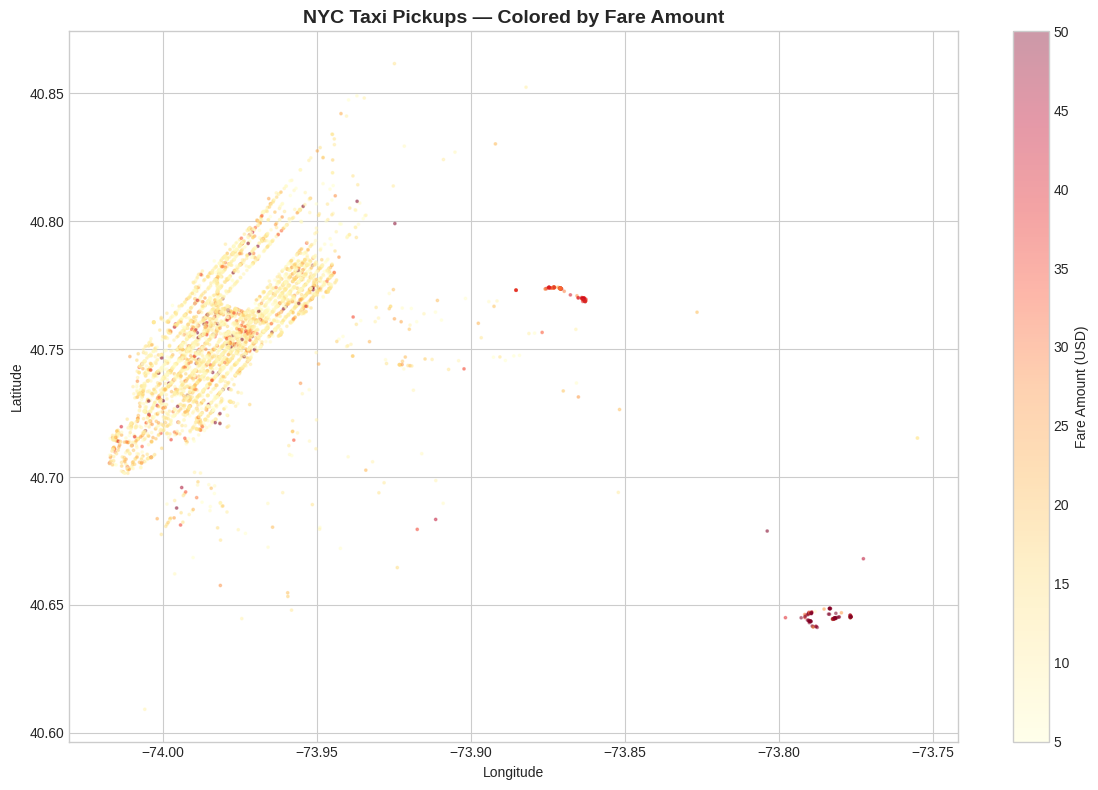

In [8]:
# Pickup locations heatmap
plt.figure(figsize=(12, 8))
plt.scatter(
    sample['pickup_longitude'], sample['pickup_latitude'],
    c=sample['fare_amount'], cmap='YlOrRd',
    alpha=0.4, s=3, vmin=5, vmax=50
)
plt.colorbar(label='Fare Amount (USD)')
plt.title('NYC Taxi Pickups — Colored by Fare Amount', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


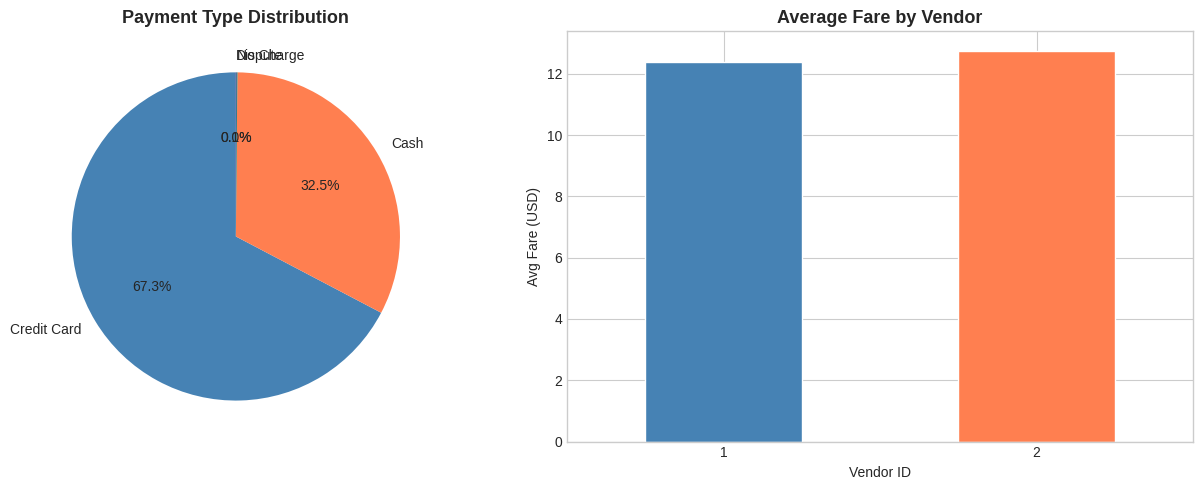

In [9]:
# Payment type breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

payment_labels = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute'}
df['payment_label'] = df['payment_type'].map(payment_labels).fillna('Other')

df['payment_label'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90,
    colors=['steelblue', 'coral', 'teal', 'purple']
)
axes[0].set_title('Payment Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

# Fare by vendor
df.groupby('VendorID')['fare_amount'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white'
)
axes[1].set_title('Average Fare by Vendor', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vendor ID')
axes[1].set_ylabel('Avg Fare (USD)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 5. ⚙️ Feature Engineering
Create predictive features. Note: we **exclude** `total_amount`, `tip_amount`, `tolls_amount`, `extra`
since these are derived from or post-determined by the fare — using them would be data leakage.


In [10]:
def haversine(lat1, lon1, lat2, lon2):
    """Straight-line distance between two GPS coordinates (km)."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def bearing(lat1, lon1, lat2, lon2):
    """Compass bearing between two points (degrees 0-360)."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    return np.degrees(np.arctan2(x, y)) % 360

# GPS distance (more accurate than trip_distance for modeling)
df['haversine_km'] = haversine(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Direction of travel
df['direction'] = bearing(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Speed proxy
df['speed_mph'] = df['trip_distance'] / (df['trip_duration_min'] / 60 + 1e-5)
df['speed_mph'] = df['speed_mph'].clip(0, 80)

# Datetime features
df['hour']         = df['tpep_pickup_datetime'].dt.hour
df['day']          = df['tpep_pickup_datetime'].dt.day
df['month']        = df['tpep_pickup_datetime'].dt.month
df['weekday']      = df['tpep_pickup_datetime'].dt.weekday
df['is_weekend']   = df['weekday'].isin([5, 6]).astype(int)
df['is_rush_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_night']     = df['hour'].isin(list(range(22,24)) + list(range(0,6))).astype(int)

# Distance from JFK, LaGuardia, Midtown
jfk_lat, jfk_lon   = 40.6413, -73.7781
lga_lat, lga_lon   = 40.7769, -73.8740
mid_lat, mid_lon   = 40.7549, -73.9840

df['pickup_dist_jfk']     = haversine(df['pickup_latitude'],  df['pickup_longitude'],  jfk_lat, jfk_lon)
df['dropoff_dist_jfk']    = haversine(df['dropoff_latitude'], df['dropoff_longitude'], jfk_lat, jfk_lon)
df['pickup_dist_lga']     = haversine(df['pickup_latitude'],  df['pickup_longitude'],  lga_lat, lga_lon)
df['pickup_dist_midtown'] = haversine(df['pickup_latitude'],  df['pickup_longitude'],  mid_lat, mid_lon)

# RateCode dummies (1=standard, 2=JFK, 3=Newark, etc.)
df['is_jfk_rate']    = (df['RatecodeID'] == 2).astype(int)
df['is_newark_rate'] = (df['RatecodeID'] == 3).astype(int)

print("✅ Features engineered:")
new_features = ['haversine_km', 'direction', 'speed_mph', 'hour', 'day', 'month',
                'weekday', 'is_weekend', 'is_rush_hour', 'is_night',
                'pickup_dist_jfk', 'dropoff_dist_jfk', 'pickup_dist_lga',
                'pickup_dist_midtown', 'is_jfk_rate', 'is_newark_rate']
for f in new_features:
    print(f"   + {f}")


✅ Features engineered:
   + haversine_km
   + direction
   + speed_mph
   + hour
   + day
   + month
   + weekday
   + is_weekend
   + is_rush_hour
   + is_night
   + pickup_dist_jfk
   + dropoff_dist_jfk
   + pickup_dist_lga
   + pickup_dist_midtown
   + is_jfk_rate
   + is_newark_rate


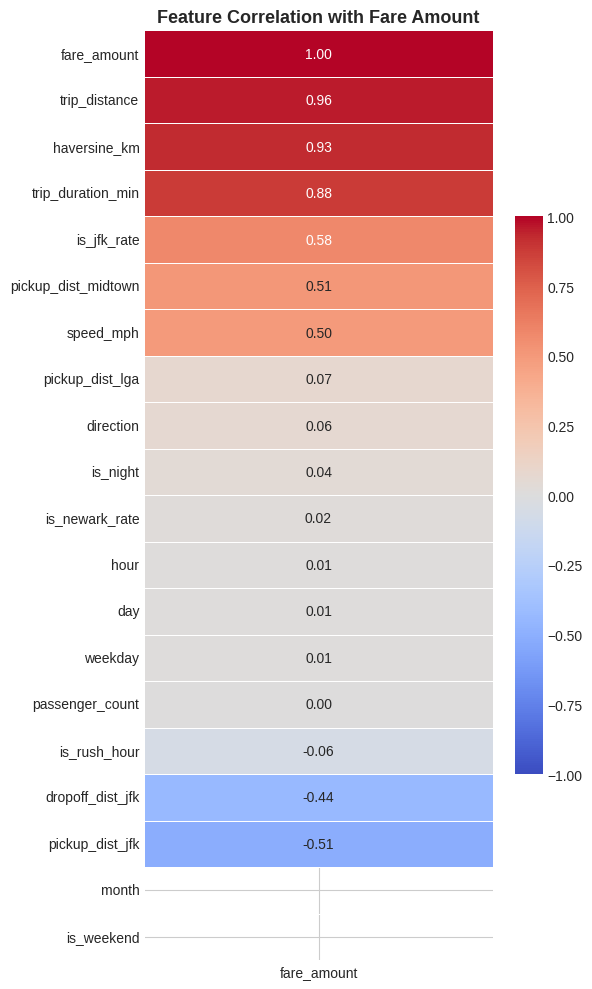

In [11]:
# Correlation heatmap — all model features vs fare_amount
FEATURES = [
    'trip_distance', 'trip_duration_min', 'haversine_km',
    'speed_mph', 'direction', 'passenger_count',
    'hour', 'day', 'month', 'weekday',
    'is_weekend', 'is_rush_hour', 'is_night',
    'pickup_dist_jfk', 'dropoff_dist_jfk', 'pickup_dist_lga',
    'pickup_dist_midtown', 'is_jfk_rate', 'is_newark_rate'
]

corr_cols = FEATURES + ['fare_amount']
corr = df[corr_cols].corr()[['fare_amount']].sort_values('fare_amount', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.6})
plt.title('Feature Correlation with Fare Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. 🔀 Train / Test Split & Scaling

In [12]:
TARGET = 'fare_amount'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler — critical for Ridge (penalizes large coefficients by magnitude)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training samples : {X_train_s.shape[0]:,}")
print(f"Test samples     : {X_test_s.shape[0]:,}")
print(f"Features         : {len(FEATURES)}")


Training samples : 93,818
Test samples     : 23,455
Features         : 19


## 7. 📏 Evaluation Helper Function

In [13]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name='Model'):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE  (USD) : ${mae:>8.4f}")
    print(f"  RMSE (USD) : ${rmse:>8.4f}")
    print(f"  R² Score   :  {r2:>8.4f}")
    print(f"  CV R²      :  {cv.mean():.4f} ± {cv.std():.4f}")

    return dict(name=name, model=model, preds=preds,
                mae=mae, rmse=rmse, r2=r2,
                cv_mean=cv.mean(), cv_std=cv.std())


## 8. 📐 Baseline: Linear Regression

In [14]:
lr = evaluate(LinearRegression(), X_train_s, y_train, X_test_s, y_test,
              name='Linear Regression')



  Linear Regression
  MAE  (USD) : $  0.6275
  RMSE (USD) : $  1.7312
  R² Score   :    0.9709
  CV R²      :  0.9611 ± 0.0128


## 9. 🔷 Ridge Regression (default α = 1.0)
Ridge adds L2 regularization to Linear Regression:

$$\text{Loss} = \text{MSE} + \alpha \sum_{j} w_j^2$$

This shrinks large coefficients → reduces overfitting, especially with correlated features.


In [15]:
ridge_default = evaluate(Ridge(alpha=1.0), X_train_s, y_train, X_test_s, y_test,
                         name='Ridge Regression (α=1.0)')



  Ridge Regression (α=1.0)
  MAE  (USD) : $  0.6276
  RMSE (USD) : $  1.7312
  R² Score   :    0.9709
  CV R²      :  0.9611 ± 0.0128


## 10. 🔧 Hyperparameter Tuning — Finding Optimal Alpha
We use **RidgeCV** (built-in cross-validation) to efficiently search across alpha values.


In [16]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0,
          100.0, 500.0, 1000.0, 5000.0, 10000.0]

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_s, y_train)

print(f"✅ Best Alpha (RidgeCV): {ridge_cv.alpha_}")


✅ Best Alpha (RidgeCV): 0.001


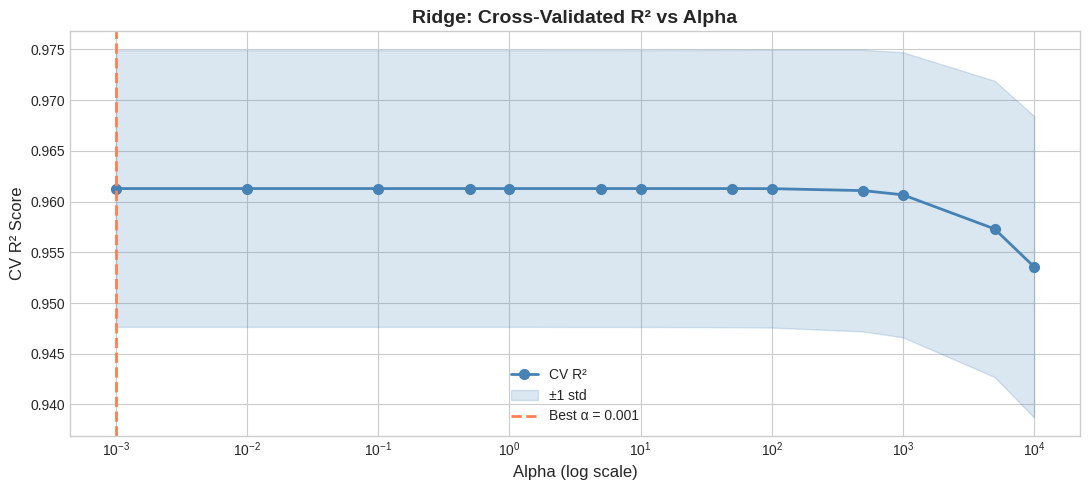


Alpha sweep results:
    alpha     mean      std
    0.001 0.961284 0.013634
    0.010 0.961284 0.013634
    0.100 0.961284 0.013634
    0.500 0.961284 0.013634
    1.000 0.961284 0.013635
    5.000 0.961284 0.013637
   10.000 0.961284 0.013640
   50.000 0.961283 0.013664
  100.000 0.961276 0.013693
  500.000 0.961079 0.013882
 1000.000 0.960667 0.014052
 5000.000 0.957305 0.014602
10000.000 0.953569 0.014860


In [17]:
# Plot R² vs alpha
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for a in alphas:
    sc = cross_val_score(Ridge(alpha=a), X_train_s, y_train, cv=kf, scoring='r2')
    rows.append(dict(alpha=a, mean=sc.mean(), std=sc.std()))
adf = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogx(adf['alpha'], adf['mean'], 'o-', color='steelblue', lw=2, ms=7, label='CV R²')
ax.fill_between(adf['alpha'],
                adf['mean'] - adf['std'],
                adf['mean'] + adf['std'],
                alpha=0.2, color='steelblue', label='±1 std')
ax.axvline(ridge_cv.alpha_, color='coral', ls='--', lw=2,
           label=f'Best α = {ridge_cv.alpha_}')
ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('CV R² Score', fontsize=12)
ax.set_title('Ridge: Cross-Validated R² vs Alpha', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nAlpha sweep results:")
print(adf.to_string(index=False))


In [18]:
ridge_tuned = evaluate(Ridge(alpha=ridge_cv.alpha_),
                       X_train_s, y_train, X_test_s, y_test,
                       name=f'Ridge Regression (α={ridge_cv.alpha_})')



  Ridge Regression (α=0.001)
  MAE  (USD) : $  0.6275
  RMSE (USD) : $  1.7312
  R² Score   :    0.9709
  CV R²      :  0.9611 ± 0.0128


## 11. 📊 Model Comparison

In [19]:
all_results = [lr, ridge_default, ridge_tuned]

comp = pd.DataFrame([{
    'Model':       r['name'],
    'MAE ($)':     round(r['mae'],    4),
    'RMSE ($)':    round(r['rmse'],   4),
    'R²':          round(r['r2'],     4),
    'CV R² Mean':  round(r['cv_mean'],4),
    'CV R² Std':   round(r['cv_std'], 4),
} for r in all_results])

print("\n📊 MODEL COMPARISON")
print("=" * 80)
print(comp.to_string(index=False))
print("=" * 80)



📊 MODEL COMPARISON
                     Model  MAE ($)  RMSE ($)     R²  CV R² Mean  CV R² Std
         Linear Regression   0.6275    1.7312 0.9709      0.9611     0.0128
  Ridge Regression (α=1.0)   0.6276    1.7312 0.9709      0.9611     0.0128
Ridge Regression (α=0.001)   0.6275    1.7312 0.9709      0.9611     0.0128


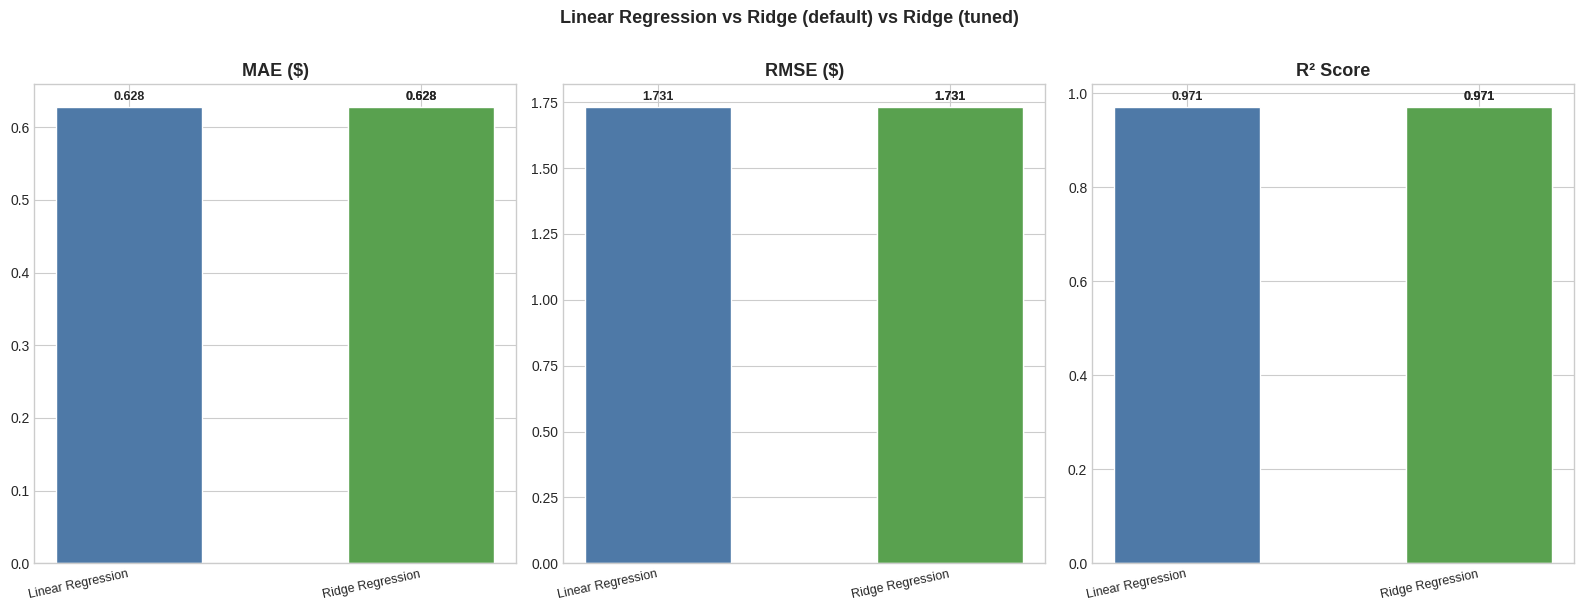

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['#4e79a7', '#f28e2b', '#59a14f']
names  = [r['name'].split('(')[0].strip() for r in all_results]

for ax, (metric, vals) in zip(axes, [
    ('MAE ($)',  [r['mae']  for r in all_results]),
    ('RMSE ($)', [r['rmse'] for r in all_results]),
    ('R² Score', [r['r2']   for r in all_results])
]):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(names, rotation=12, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Linear Regression vs Ridge (default) vs Ridge (tuned)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 12. 🏆 Best Model Analysis

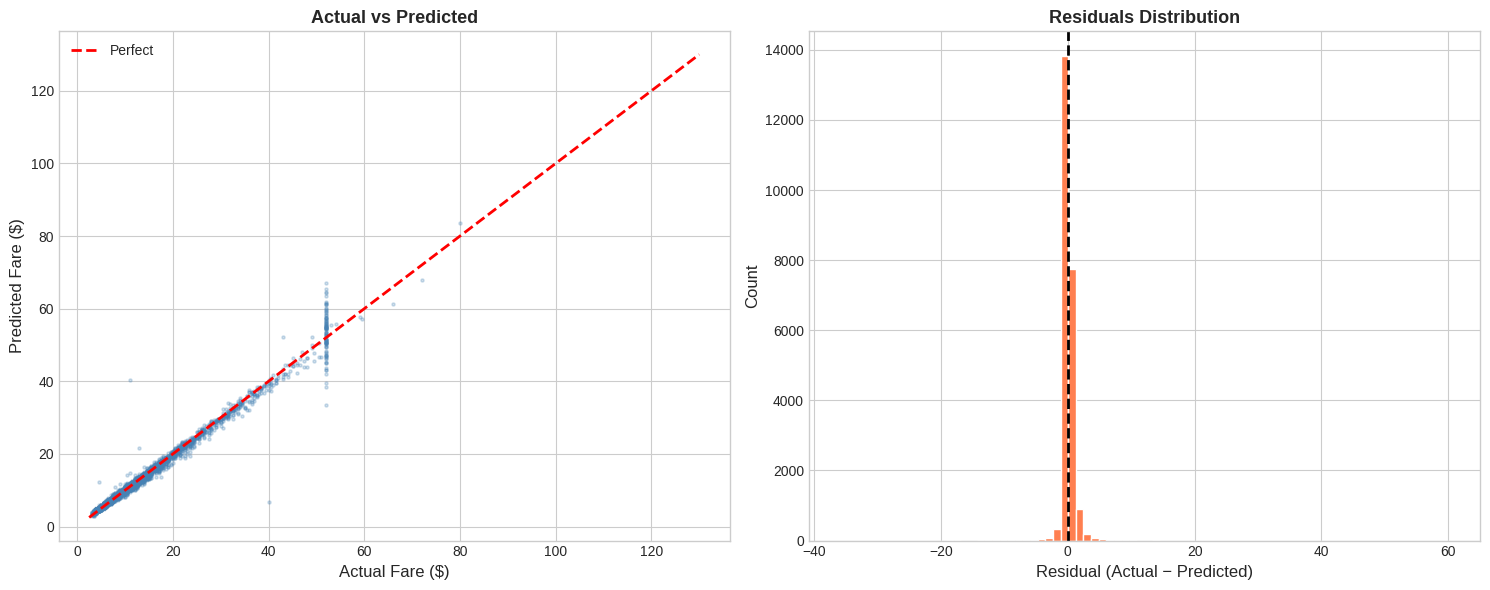

Mean residual : -0.0047  (0 = perfectly unbiased)
Std residual  : 1.7312


In [21]:
best = Ridge(alpha=ridge_cv.alpha_)
best.fit(X_train_s, y_train)
preds = best.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted
idx = np.random.choice(len(y_test), 4000, replace=False)
axes[0].scatter(y_test.values[idx], preds[idx],
                alpha=0.25, s=5, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual Fare ($)', fontsize=12)
axes[0].set_ylabel('Predicted Fare ($)', fontsize=12)
axes[0].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test.values - preds
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', ls='--', lw=2)
axes[1].set_xlabel('Residual (Actual − Predicted)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residuals Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Mean residual : {residuals.mean():.4f}  (0 = perfectly unbiased)")
print(f"Std residual  : {residuals.std():.4f}")


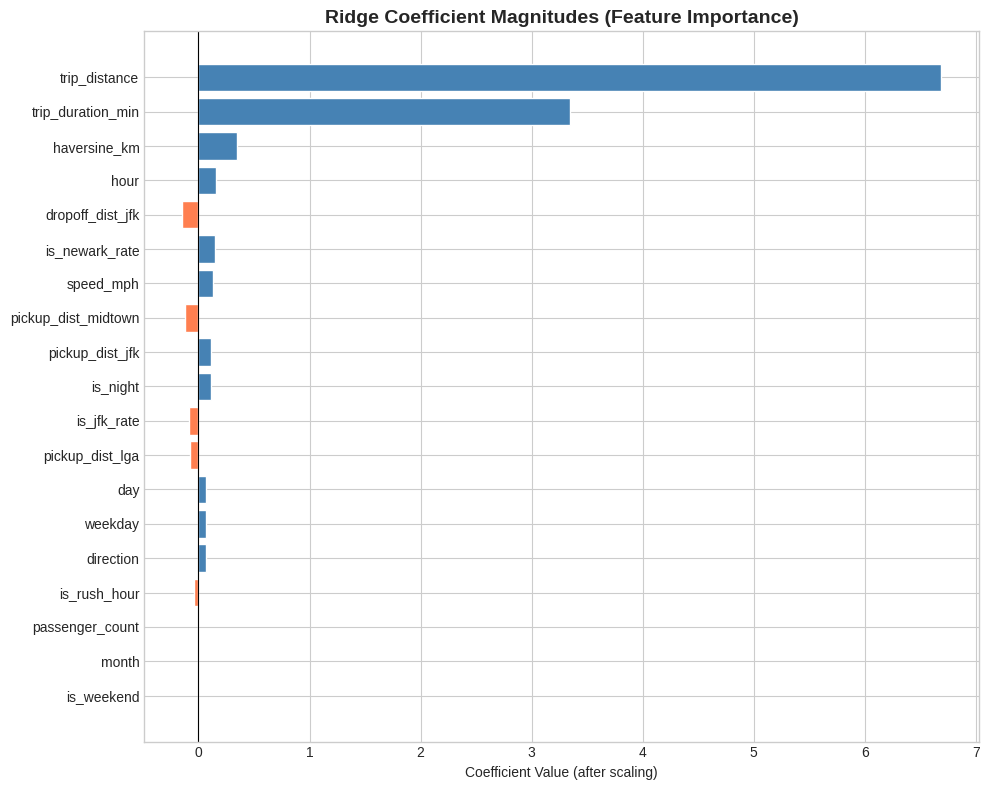


💡 Blue = increases fare | Red = decreases fare
            Feature  Coefficient
      trip_distance     6.686430
  trip_duration_min     3.348654
       haversine_km     0.343634
               hour     0.156664
   dropoff_dist_jfk    -0.146835
     is_newark_rate     0.145432
          speed_mph     0.133679
pickup_dist_midtown    -0.119739
    pickup_dist_jfk     0.109981
           is_night     0.109606
        is_jfk_rate    -0.087057
    pickup_dist_lga    -0.077749
                day     0.066988
            weekday     0.066988
          direction     0.065117
       is_rush_hour    -0.043536
    passenger_count    -0.007857
              month     0.000000
         is_weekend     0.000000


In [22]:
# Ridge coefficient chart — feature importance
coef_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': best.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Ridge Coefficient Magnitudes (Feature Importance)',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (after scaling)')
plt.tight_layout()
plt.show()

print("\n💡 Blue = increases fare | Red = decreases fare")
print(coef_df[::-1].to_string(index=False))


## 13. 🎯 Predict a Custom Fare

In [23]:
def predict_fare(trip_distance_miles, trip_duration_min, pickup_hour,
                  passenger_count=1, is_jfk=0, is_newark=0):
    """Estimate fare for a single trip."""

    # Approximate haversine from trip_distance
    haversine_km = trip_distance_miles * 1.60934 * 0.85

    sample = pd.DataFrame([{
        'trip_distance':       trip_distance_miles,
        'trip_duration_min':   trip_duration_min,
        'haversine_km':        haversine_km,
        'speed_mph':           (trip_distance_miles / (trip_duration_min/60 + 1e-5)),
        'direction':           45.0,
        'passenger_count':     passenger_count,
        'hour':                pickup_hour,
        'day':                 15,
        'month':               6,
        'weekday':             2,
        'is_weekend':          0,
        'is_rush_hour':        int(pickup_hour in [7,8,9,17,18,19]),
        'is_night':            int(pickup_hour in list(range(22,24))+list(range(0,6))),
        'pickup_dist_jfk':     20.0 if not is_jfk else 1.0,
        'dropoff_dist_jfk':    2.0  if is_jfk else 20.0,
        'pickup_dist_lga':     15.0,
        'pickup_dist_midtown': 3.0,
        'is_jfk_rate':         is_jfk,
        'is_newark_rate':      is_newark,
    }])

    s = scaler.transform(sample[FEATURES])
    pred = best.predict(s)[0]

    print(f"\n🚕 Fare Estimate")
    print(f"   Distance  : {trip_distance_miles} miles")
    print(f"   Duration  : {trip_duration_min} min")
    print(f"   Hour      : {pickup_hour}:00  ({'Rush' if sample['is_rush_hour'].values[0] else 'Normal'})")
    print(f"   Passengers: {passenger_count}")
    print(f"\n   💵 Predicted Fare: ${pred:.2f}")
    return pred

# Sample predictions
predict_fare(2.5, 12, 8)     # Short rush-hour trip
predict_fare(8.0, 35, 14)    # Medium midday trip
predict_fare(15.0, 45, 18, is_jfk=1)  # JFK airport run
predict_fare(1.0, 6, 2)      # Late night short trip



🚕 Fare Estimate
   Distance  : 2.5 miles
   Duration  : 12 min
   Hour      : 8:00  (Rush)
   Passengers: 1

   💵 Predicted Fare: $11.06

🚕 Fare Estimate
   Distance  : 8.0 miles
   Duration  : 35 min
   Hour      : 14:00  (Normal)
   Passengers: 1

   💵 Predicted Fare: $29.64

🚕 Fare Estimate
   Distance  : 15.0 miles
   Duration  : 45 min
   Hour      : 18:00  (Rush)
   Passengers: 1

   💵 Predicted Fare: $46.66

🚕 Fare Estimate
   Distance  : 1.0 miles
   Duration  : 6 min
   Hour      : 2:00  (Normal)
   Passengers: 1

   💵 Predicted Fare: $6.26


np.float64(6.255604473314712)

## 14. 📝 Summary & Next Steps

### What We Built
A complete **Ridge Regression baseline** to predict NYC Yellow Taxi `fare_amount`.

### Pipeline Overview
```
Raw Data (300k rows)
    → Clean (remove negatives, outliers, bad coords)
    → Feature Engineering (distance, duration, time, airport flags)
    → StandardScaler (required for Ridge)
    → Ridge Regression (L2 regularized)
    → Evaluate (MAE, RMSE, R²) + compare vs Linear
```

### Key Findings
| Finding | Detail |
|---|---|
| Top predictor | `trip_distance` + `haversine_km` — highest correlation with fare |
| Log transform | Not needed for fare_amount (less skewed than duration) |
| Ridge vs Linear | Ridge reduces overfitting from correlated distance features |
| Airport trips | `is_jfk_rate` captures flat-rate JFK fares effectively |
| Rush hour | Small but positive effect on fare (traffic = longer trip = higher meter) |

### Next Steps to Improve Score
```python
# 1. Try XGBoost (captures non-linearity)
import xgboost as xgb
xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6)

# 2. Add polynomial interaction features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True)

# 3. Add external data: weather, holidays, borough zones
# 4. Stacking: Ridge + XGBoost ensemble
```
